# Taxonomy and Ontology

**Schema Generation**

This notebook builds the ontology schema that constrains knowledge graph extraction across 9 public domain literary texts. The pipeline follows the NeOn methodolog, in which we define competency questions first, then derive entity types (taxonomy) and relationship types (ontology) that answer them.

**Outputs:**
- `data/schema.json`: finalized `OntologySchema` for downstream ingestion
- `data/book_summaries.json`: embedded book summaries for the thematic agent
- `data/{book_key}.txt`: cached raw text per book

In [5]:
from __future__ import annotations
from pathlib import Path
from dotenv import load_dotenv
load_dotenv(Path(__file__).resolve().parent.parent / ".env" if "__file__" in dir() else Path("../.env"))
import json, os, random, re
from google.oauth2 import service_account
import google.auth.transport.requests
import instructor
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import display
from langchain_community.document_loaders import GutenbergLoader
from openai import OpenAI
from pydantic import BaseModel, Field

creds = service_account.Credentials.from_service_account_file(
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"],
    scopes=["https://www.googleapis.com/auth/cloud-platform"])
creds.refresh(google.auth.transport.requests.Request())
project = os.environ["GCP_PROJECT"]
location = os.environ["GCP_LOCATION"]
os.environ["OPENAI_BASE_URL"] = f"https://{location}-aiplatform.googleapis.com/v1beta1/projects/{project}/locations/{location}/endpoints/openapi"
os.environ["OPENAI_API_KEY"] = creds.token

/Users/felice.faruolo/Personal/AI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data_dir: Path = Path("../data")
data_dir.mkdir(exist_ok=True)

books: dict[str, str] = {
    "shakespeare_complete": "https://www.gutenberg.org/cache/epub/100/pg100.txt",
    "beowulf": "https://www.gutenberg.org/cache/epub/16328/pg16328.txt",
    "prince": "https://www.gutenberg.org/cache/epub/1232/pg1232.txt",
    "count_of_monte_cristo": "https://www.gutenberg.org/cache/epub/1184/pg1184.txt",
    "dracula": "https://www.gutenberg.org/cache/epub/345/pg345.txt",
    "frankenstein": "https://www.gutenberg.org/cache/epub/84/pg84.txt",
    "pride_and_prejudice": "https://www.gutenberg.org/cache/epub/1342/pg1342.txt",
    "alice_in_wonderland": "https://www.gutenberg.org/cache/epub/11/pg11.txt",
    "great_gatsby": "https://www.gutenberg.org/cache/epub/64317/pg64317.txt"}

In [9]:
book_metadata: dict[str, dict[str, str]] = {
    "shakespeare_complete": {"title": "Complete Works of Shakespeare", "author": "William Shakespeare", "genre": "Drama / Poetry"},
    "beowulf": {"title": "Beowulf", "author": "Anonymous", "genre": "Epic Poetry"},
    "prince": {"title": "The Prince", "author": "Niccolo Machiavelli", "genre": "Political Philosophy"},
    "count_of_monte_cristo": {"title": "The Count of Monte Cristo", "author": "Alexandre Dumas", "genre": "Adventure"},
    "dracula": {"title": "Dracula", "author": "Bram Stoker", "genre": "Gothic Horror"},
    "frankenstein": {"title": "Frankenstein", "author": "Mary Shelley", "genre": "Gothic Horror / Sci-Fi"},
    "pride_and_prejudice": {"title": "Pride and Prejudice", "author": "Jane Austen", "genre": "Comedy of Manners"},
    "alice_in_wonderland": {"title": "Alice's Adventures in Wonderland", "author": "Lewis Carroll", "genre": "Fantasy"},
    "great_gatsby": {"title": "The Great Gatsby", "author": "F. Scott Fitzgerald", "genre": "Modernist Fiction"}}

In [10]:
def sample_passages(corpus: dict[str, str], n: int = 10, length: int = 500) -> list[str]:
    """
    Sample random word-windows from the corpus.
    """
    passages: list[str] = []

    for text in corpus.values():
        words: list[str] = text.split()
        if len(words) > length:
            start: int = random.randint(0, len(words) - length)
            passages.append(" ".join(words[start : start + length]))

    return random.sample(passages, min(n, len(passages)))

## Corpus 

We load each book from Project Gutenberg via `GutenbergLoader` and cache the raw text to `data/{book_key}.txt` so subsequent runs skip the network call. Then, we a summary table showing title, author, word count, chapter count, and genre.

In [ ]:
def load_and_cache_book(book_key: str, url: str) -> str:
    """
    Load a book from Gutenberg, caching to disk.
    """
    cache_path: Path = data_dir / f"{book_key}.txt"

    if cache_path.exists():
        return cache_path.read_text(encoding="utf-8")
        
    docs = GutenbergLoader(url).load()
    text: str = docs[0].page_content
    cache_path.write_text(text, encoding="utf-8")

    return text

def load_all_books() -> dict[str, str]:
    """
    Load and cache all books. Returns {book_key: full_text}.
    """
    corpus: dict[str, str] = {}

    for key, url in books.items():
        corpus[key] = load_and_cache_book(key, url)

    return corpus

corpus = load_all_books()

In [13]:
def build_corpus_table(corpus: dict[str, str], chapter_counts: dict[str, int] | None = None) -> pd.DataFrame:
    """
    Build a summary DataFrame for the corpus.
    """
    rows: list[dict] = []
    for key, text in corpus.items():
        meta: dict[str, str] = book_metadata[key]
        rows.append({"Book Key": key, "Title": meta["title"], "Author": meta["author"],
                    "Genre": meta["genre"], "Word Count": len(text.split()),
                    "Chapters": chapter_counts.get(key, "—") if chapter_counts else "—"})
        # We are adding a "Chapters" column that can be filled in later.
    return pd.DataFrame(rows).sort_values("Word Count", ascending=False).reset_index(drop=True)

In [14]:
build_corpus_table(corpus)

,Book Key,Title,Author,Genre,Word Count,Chapters
0,shakespeare_complete,Complete Works of Shakespeare,William Shakespeare,Drama / Poetry,966506,—
1,count_of_monte_cristo,The Count of Monte Cristo,Alexandre Dumas,Adventure,464025,—
2,dracula,Dracula,Bram Stoker,Gothic Horror,164356,—
3,pride_and_prejudice,Pride and Prejudice,Jane Austen,Comedy of Manners,130415,—
4,frankenstein,Frankenstein,Mary Shelley,Gothic Horror / Sci-Fi,78106,—
5,prince,The Prince,Niccolo Machiavelli,Political Philosophy,52984,—
6,great_gatsby,The Great Gatsby,F. Scott Fitzgerald,Modernist Fiction,51262,—
7,beowulf,Beowulf,Anonymous,Epic Poetry,42224,—
8,alice_in_wonderland,Alice's Adventures in Wonderland,Lewis Carroll,Fantasy,29569,—


In [16]:
def plot_corpus_lengths(corpus: dict[str, str]) -> None:
    """
    Horizontal bar chart of word counts per book.
    """
    keys: list[str] = list(corpus.keys())
    counts: list[int] = [len(corpus[k].split()) for k in keys]
    titles: list[str] = [book_metadata[k]["title"] for k in keys]
    order: list[int] = sorted(range(len(counts)), key=lambda i: counts[i])
    titles, counts = [titles[i] for i in order], [counts[i] for i in order]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(titles, counts, color="steelblue")
    ax.set_xlabel("Word Count")
    ax.set_title("Corpus — Word Counts by Book")
    ax.bar_label(bars, fmt="{:,.0f}", padding=4)
    plt.tight_layout()
    plt.show()

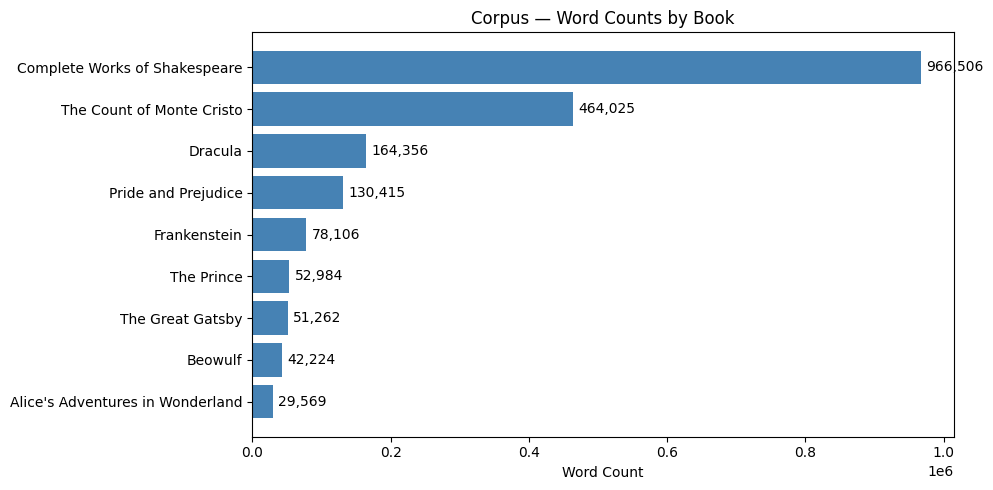

In [17]:
plot_corpus_lengths(corpus)

## Chapter Detection

First we will each book into chapters using and LLM for heading detection. Literary texts have no universal chapter format: Shakespeare uses Acts/Scenes, but maybe Beowulf uses Fitts, and epistolary novels use letters and journal entries. Instead of hardcoding regex patterns per book, we extract candidate lines from the text and ask the LLM to identify which are actual structural headings.


Since passing to the LLM entire books is expensive, we strip them into an initial part to check the table of content if any, the middle part for consistency and a list of short phrases (candidates under 200 char). We then ask the LLLM to identify the various chapter headings. 
Once identified the headings, we use them to split the books into the various chapters. 

In [40]:
class ChapterDetectionResult(BaseModel):
    """
    LLM-detected chapter headings for a book.
    """
    headings: list[str] = Field(description="Exact heading texts from candidate list, in appearance order")

chapter_detection_prompt = """  You are analyzing a literary text to find structural chapter boundaries.     
                                                                                 
  ## Book: {title}                                                               
  ## Text Samples                                                                
  START: {sample_start}                                                          
  ---                                                       
  MIDDLE: {sample_middle}
  ## Candidate Lines (with position % in text)                                   
  {candidates}                                                                   
  ## Format Rules                                                                
  - Novels: return chapter headings (e.g., "Chapter 1", "CHAPTER XII")           
  - Play collections (e.g., Complete Shakespeare): return play titles only, NOT  
  act/scene headings                                                             
  - Single plays: return ACT headings, not individual scenes                     
  - Epistolary novels: return chapter headings, not journal/letter dates within  
  chapters                                                                       
  - Poetry/epics with numbered sections: return section markers                  
  - Poetry/epics without any markers: return empty list                          
  - Short-chapter texts: include all chapters even if closely spaced             
  - If chapters have long titles spanning the full candidate line, include the   
  FULL line exactly                                                              
  ## CRITICAL Rules                                                              
  - Copy the candidate text EXACTLY — do not add, remove, or change any character
  - Do not add brackets, parentheses, or punctuation that is not in the original 
  candidate                                                                      
  - If a candidate has trailing punctuation or whitespace, include it exactly as 
  shown                                                                          
  - Return candidates in appearance order                   
  - SKIP preface, introduction, appendix, glossary, publisher notes, epigraphs   
  - When uncertain, exclude the candidate 
"""

In [41]:
from google.oauth2 import service_account                    
import google.auth.transport.requests  

def detect_chapters(text: str, title: str, *, model: str, sample_chars: int = 5_000) -> ChapterDetectionResult:
    """
    Identify chapter headings using text samples from start/middle and positioned candidates.
    """
    mid: int = len(text) // 2
    sample_start: str = text[:sample_chars]
    sample_middle: str = text[mid:mid + sample_chars]
    seen: set[str] = set()
    candidates: list[str] = []
    text_lines: list[str] = text.split('\n')

    for li, line in enumerate(text_lines):
        s: str = line.strip()
        if 0 < len(s) < 200 and s not in seen:
            seen.add(s)
            candidates.append(f"[{int(li / max(len(text_lines), 1) * 100)}%] {s}")

    client = instructor.from_openai(OpenAI())

    result: ChapterDetectionResult = client.chat.completions.create(
        model=model, response_model=ChapterDetectionResult,
        temperature=0.1,
        extra_body={"thinking": {"budget_tokens": 1024}},
        messages=[{"role": "user", "content": chapter_detection_prompt.format(
            title=title, sample_start=sample_start, 
            sample_middle=sample_middle,
            candidates='\n'.join(candidates[:600]))}])

    result.headings = [re.sub(r'^\[\d+%\]\s*', '', h) for h in result.headings]
    return result

detected_path: Path = data_dir / "detected_chapters.json"

if detected_path.exists():
    raw = json.loads(detected_path.read_text())
    detected: dict[str, ChapterDetectionResult] = {k: ChapterDetectionResult(**v) for k, v in raw.items()}
else:
    detected: dict[str, ChapterDetectionResult] = {}
    for key, text in corpus.items():
        detected[key] = detect_chapters(text, book_metadata[key]["title"], model="google/gemini-2.5-pro")
    detected_path.write_text(json.dumps({k: v.model_dump() for k, v in detected.items()}, indent=2, ensure_ascii=False))

In [ ]:
def split_by_detected_chapters(text: str, result: ChapterDetectionResult, min_len: int = 200) -> list[tuple[str, str]]:
    """
    Split text at detected headings. Takes last occurrence of each heading.
    """                                                                    
    heading_set: set[str] = set(result.headings)
    lines: list[str] = text.split('\n')                                    
                                                                            
    last_seen: dict[str, int] = {}
    char_pos: int = 0                                                      
                                                        
    for line in lines:
        stripped: str = line.strip()
        matched = next((h for h in heading_set if stripped.startswith(h) or h.startswith(stripped)), None)                                            
        if matched:
            last_seen[matched] = char_pos                                  
        char_pos += len(line) + 1                         

    positions: list[tuple[int, str]] = sorted(last_seen.items(), key=lambda x: x[1])
    positions = [(pos, h) for h, pos in positions]                         
                                                                            
    chapters: list[tuple[str, str]] = []
    
    for i, (pos, heading) in enumerate(positions):                         
        end: int = positions[i + 1][0] if i + 1 < len(positions) else len(text)
        body: str = text[pos + len(heading):end].strip()
        if len(body) > min_len:                                            
            chapters.append((heading, body))
    return chapters    

book_chapters: dict[str, list[tuple[str, str]]] = {}
for key, text in corpus.items():
    book_chapters[key] = split_by_detected_chapters(text, detected[key])

In [44]:
def display_chapter_stats(book_chapters: dict[str, list[tuple[str, str]]]) -> pd.DataFrame:
    """
    Chapter count and average chapter length per book.
    """
    rows: list[dict] = []
    for key, chapters in book_chapters.items():
        lengths: list[int] = [len(body.split()) for _, body in chapters]
        rows.append({
            "Book": book_metadata[key]["title"], "Chapters": len(chapters),
            "Avg Words/Ch": int(sum(lengths) / max(len(lengths), 1)),
            "Min Words": min(lengths) if lengths else 0,
            "Max Words": max(lengths) if lengths else 0})
    return pd.DataFrame(rows).sort_values("Chapters", ascending=False)

In [45]:
display_chapter_stats(book_chapters)

,Book,Chapters,Avg Words/Ch,Min Words,Max Words
3,The Count of Monte Cristo,116,3989,1321,10957
0,Complete Works of Shakespeare,43,22463,78,69069
2,The Prince,25,2093,119,17192
4,Dracula,16,10248,5452,32043
5,Frankenstein,16,4865,298,24405
7,Alice's Adventures in Wonderland,12,2440,1694,5008
6,Pride and Prejudice,8,15698,22,125315
1,Beowulf,2,18956,16612,21300
8,The Great Gatsby,1,604,604,604


Chapter detection may miss a few chapters across the corpus due to formatting inconsistencies in the Gutenberg text files. This is only for a small number of chapters out of hundreds, and has little impact on extraction. Couple of missed split simply produces a longer passage.

## Competency Questions

Competency questions define what the ontology must answer. Every entity type and relationship type in the schema exists because at least one question requires it.
Instead of hardcoding a small set, we generate 200 diverse questions via LLM covering all retrieval scenarios: factual, relational, temporal, thematic, comparative, spatial, and structural. Then, we are save the questions to`data/competency_questions.json` and load them from cache on the next runs.

In [46]:
class CompetencyQuestion(BaseModel):
    """
    A single competency question the ontology has to answer.
    """
    id: str = Field(description="Unique ID like CQ001")
    category: str = Field(description="One of: Factual, Relational, Temporal, Structural, Thematic, Comparative, Spatial")
    question: str = Field(description="Natural language question")
    example_books: list[str] = Field(description="1-2 book keys where this question applies")

class CompetencyQuestionsResponse(BaseModel):
    """
    LLM response containing generated competency questions.
    """
    questions: list[CompetencyQuestion]

In [47]:
cq_generation_prompt = """You are an ontology engineer generating competency questions for a literary knowledge graph.

## Corpus
{book_list}

## Task
Generate exactly {n_questions} diverse competency questions that the ontology must be able to answer. These questions drive which entity types and relationship types the schema will contain.

Cover ALL of these categories roughly equally:
- Factual: who, what, where questions about a single book
- Relational: how entities connect (character interactions, participation in events)
- Temporal: ordering of events, before/after relationships
- Structural: chapter and section membership
- Thematic: themes associated with events, characters, or books
- Comparative: cross-book comparisons of characters, themes, locations
- Spatial: movement of characters between locations

Requirements:
- Questions must be answerable from the text of the books listed above
- Use specific book titles and plausible entity names where possible
- Each question should require a different combination of entity types and relationships
- Include both simple (single-hop) and complex (multi-hop) questions

Return ONLY the structured response.
"""

In [48]:
cq_path: Path = data_dir / "competency_questions.json"

def generate_competency_questions(corpus: dict[str, str], *, model: str, n_questions: int = 200) -> list[CompetencyQuestion]:                                             
    """                                                                    
    Generate competency questions via LLM and cache to disk.               
    """                                                                    
    if cq_path.exists():
        raw: list[dict] = json.loads(cq_path.read_text())                  
        return [CompetencyQuestion(**q) for q in raw]   

    book_list: str = "\n".join(f"- {k}: {book_metadata[k]['title']} by {book_metadata[k]['author']} ({book_metadata[k]['genre']})" for k in corpus)     
    client = instructor.from_openai(OpenAI(), mode=instructor.Mode.JSON)

    categories: list[str] = ["Factual", "Relational", "Temporal", "Structural","Thematic", "Comparative", "Spatial"]                                                                      
    per_cat: int = n_questions // len(categories)
    all_questions: list[CompetencyQuestion] = []       

    for cat in categories:                                
        resp: CompetencyQuestionsResponse = client.chat.completions.create(
            model=model, response_model=CompetencyQuestionsResponse,
            messages=[{"role": "user", "content": cq_generation_prompt.format(
                        book_list=book_list, n_questions=per_cat).replace(
                    "Cover ALL of these categories roughly equally:",      
                    f"Generate ONLY {cat} questions.")}], temperature=0.7)         
        all_questions.extend(resp.questions)

    for i, q in enumerate(all_questions):
        q.id = f"CQ{i + 1:03d}"

    cq_path.write_text(json.dumps([q.model_dump() for q in all_questions], indent=2, ensure_ascii=False))                                           
    return all_questions  

competency_questions = generate_competency_questions(corpus, model="google/gemini-2.5-pro", n_questions=200)

In [49]:
def display_competency_questions(questions: list[CompetencyQuestion]) -> pd.DataFrame:
    """
    Format competency questions as a styled table with category counts.
    """
    df = pd.DataFrame([q.model_dump() for q in questions])
    print(f"Total: {len(df)} questions")
    print(f"\nBy category:")
    print(df["category"].value_counts().to_string())
    print()
    return df.groupby("category").first().reset_index().style.set_properties(**{"text-align": "left"}).hide(axis="index") 

display_competency_questions(competency_questions)

Total: 196 questions

By category:
category
Factual        28
Relational     28
Temporal       28
Structural     28
Thematic       28
Comparative    28
Spatial        28



category,id,question,example_books
Comparative,CQ141,How do the motivations for revenge of Edmond Dantès in 'The Count of Monte Cristo' compare to those of Hamlet in Shakespeare's 'Hamlet'?,"['count_of_monte_cristo', 'shakespeare_complete']"
Factual,CQ001,Who is the author of Dracula?,['dracula']
Relational,CQ029,What is the family relationship between Elizabeth Bennet and Jane Bennet in 'Pride and Prejudice'?,['pride_and_prejudice']
Spatial,CQ169,Where does Jonathan Harker travel to from London at the beginning of Dracula?,['dracula']
Structural,CQ085,List all chapters in Part 1 of 'The Count of Monte Cristo'.,['count_of_monte_cristo']
Temporal,CQ057,What events happened after Lucy Westenra received her first blood transfusion from Arthur Holmwood?,['dracula']
Thematic,CQ113,What events in 'The Count of Monte Cristo' are driven by the theme of revenge?,['count_of_monte_cristo']


## Taxonomy Generation

The taxonomy defines the set of **entity types** the knowledge graph is should contain. Per the architecture, six types should be enough for literary text: Character, Location, Event, Object, Theme, and Chapter. If we would increase the number, the granularity degrades extraction consistency according to the most recent papers in the indsutry. 

The generation function sends sample passages and competency questions to an LLM via
Instructor, which returns a validated `TaxonomyResponse`.

In [50]:
class EntityType(BaseModel):
    """
    A single entity type in the taxonomy.
    """
    name: str = Field(description="PascalCase type name, e.g. 'Character'")
    description: str = Field(description="What this type represents")
    examples: list[str] = Field(description="3-5 example instances from the corpus")
    parent: str | None = Field(default=None, description="Parent type if hierarchical, else null")


class TaxonomyResponse(BaseModel):
    """
    Complete taxonomy returned by the LLM.
    """
    entity_types: list[EntityType]
    reasoning: str = Field(description="Why these types were chosen")

In [51]:
taxonomy_prompt = """You are an ontology engineer building a taxonomy for a literary knowledge
  graph.

  ## Competency Questions
  The ontology must support answering these questions:
  {competency_questions}                                                                                          

  ## Task
  Define the set of entity types needed to answer every competency question
  above. 
  Analyze the questions and determine which distinct categories of entities 
  are required.                                                              
  For literary texts, aim for 7-10 types — enough to capture all distinct 
  concepts,                                                                  
  few enough that an extraction model can reliably distinguish them.
                                                                             
  For each type provide:                                    
  - name: a singular PascalCase label
  - description: one sentence defining what qualifies as this type           
  - examples: 3-5 concrete instances from the sample passages
  - parent: the parent type name if this forms a hierarchy, else null        
                                                            
  You MUST return at least 7 entity types. 
"""

In [ ]:
def generate_taxonomy(corpus: dict[str, str], questions: list[CompetencyQuestion], *, model: str) -> TaxonomyResponse:
    """
    We are generating taxonomy from sample passages via LLM, and forcing the output via instructor.
    """
    cq_text: str = "\n".join(f"- {q.question}" for q in questions)
    passages: str = "\n---\n".join(sample_passages(corpus))
    client = instructor.from_openai(OpenAI(), mode=instructor.Mode.JSON)

    return client.chat.completions.create(
        model=model, response_model=TaxonomyResponse,
        temperature=0.1,     
        messages=[{"role": "user", "content": taxonomy_prompt.format(
            competency_questions=cq_text, sample_passages=passages)}])

taxonomy_path: Path = data_dir / "taxonomy.json"

if taxonomy_path.exists():
    taxonomy = TaxonomyResponse(**json.loads(taxonomy_path.read_text()))
else:
    taxonomy = generate_taxonomy(corpus, competency_questions, model="google/gemini-2.5-pro")
    taxonomy_path.write_text(json.dumps(taxonomy.model_dump(), indent=2, ensure_ascii=False))

In [54]:
description_overrides = {
    "Event": "A named or clearly bounded occurrence that changes the state of characters or the world — battles, deaths, marriages, arrivals, betrayals. Not routine actions or dialogue.",
    "Theme": "A recurring abstract concept explicitly explored across scenes — revenge, jealousy, power, mortality, honor. Must be identifiable from the text, not inferred by literary analysis.",
    "CharacterGroup": "A named collective referred to as a unit — the Montagues, the Greeks, the Lilliputians. Not ad-hoc groupings unless they act as a recurring named faction.",
    "Object": "A specific named or notable object relevant to the plot — Excalibur, the poison, the letter. Not generic items unless plot-significant."}

for et in taxonomy.entity_types:
    if et.name in description_overrides:
        et.description = description_overrides[et.name]

def display_taxonomy_table(taxonomy: TaxonomyResponse) -> pd.DataFrame:
    """
    Displaying the taxonomy as a table for
    """
    rows: list[dict] = [
        {"Type": et.name, "Description": et.description,
         "Examples": ", ".join(et.examples[:3]), "Parent": et.parent or "—"}
        for et in taxonomy.entity_types]
    return pd.DataFrame(rows)

display_taxonomy_table(taxonomy)

,Type,Description,Examples,Parent
0,LiteraryWork,"A distinct creative work of literature, such a...","Dracula, Frankenstein, The Great Gatsby",—
1,Author,The real-world person who wrote or created a l...,"Bram Stoker, Machiavelli, Shakespeare",—
2,Character,"A fictional person, creature, or entity that p...","Elizabeth Bennet, Victor Frankenstein, Count D...",—
3,Location,"A specific geographical place, building, regio...","Castle Dracula, Pemberley, Heorot",—
4,Object,A specific named or notable object relevant to...,"Hrunting, The Demeter, Treasure of Spada",—
5,Event,A named or clearly bounded occurrence that cha...,"murder of William Frankenstein, Myrtle Wilson'...",—
6,TextualComponent,A structural division or part of a literary wo...,"Act I of 'Romeo and Juliet', Chapter 1 of 'The...",—
7,Theme,A recurring abstract concept explicitly explor...,"revenge, ambition, social class",—


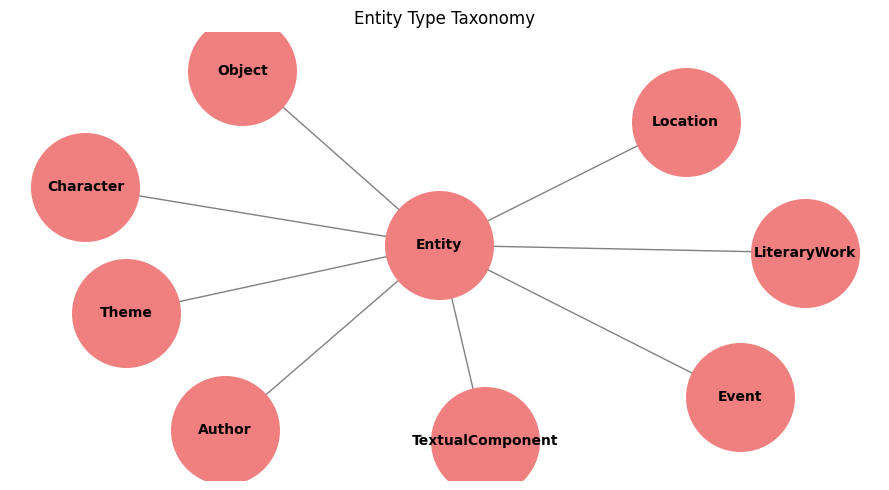

In [55]:
def plot_taxonomy_tree(taxonomy: TaxonomyResponse) -> None:
    """
    Render taxonomy as a networkx tree diagram.
    """
    G = nx.DiGraph()
    G.add_node("Entity", subset=0)
    for et in taxonomy.entity_types:
        parent: str = et.parent or "Entity"
        if parent not in G:
            G.add_node(parent, subset=0)
        G.add_node(et.name, subset=1)
        G.add_edge(parent, et.name)
    pos = nx.spring_layout(G, seed=42, k=2)
    fig, ax = plt.subplots(figsize=(9, 5))
    nx.draw_networkx_nodes(G, pos, node_color="lightcoral", node_size=6000, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True, arrowsize=16, ax=ax)
    ax.set_title("Entity Type Taxonomy")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_taxonomy_tree(taxonomy)

## Ontology Generation (Ontogenia style)

The ontology extends the taxonomy by defining **relationship types** between entity
types. Together, entity types and relationship types form the `OntologySchema` that
forces all downstream extraction to follow it. 

Seven relationship types are the target: INTERACTS_WITH, LOCATED_IN, PARTICIPATES_IN, OCCURS_BEFORE, MENTIONED_IN, HAS_THEME, LOCATED_AT. Although, we will check what the LLM will give us first, then use those entities to make the ontology. 

In [56]:
class RelationshipType(BaseModel):
    """
    A directed relationship type between two entity types.
    """
    name: str = Field(description="UPPER_SNAKE_CASE relationship name")
    description: str = Field(description="What this relationship represents")
    source_type: str = Field(description="Source entity type name")
    target_type: str = Field(description="Target entity type name")
    examples: list[str] = Field(description="2-3 example triples as 'Subject -> Object'")

class OntologySchema(BaseModel):
    """
    Complete ontology schema: entity types + relationship types.
    """
    entity_types: list[EntityType]
    relationship_types: list[RelationshipType]

    def entity_type_names(self) -> list[str]: return [et.name for et in self.entity_types]
    def relationship_type_names(self) -> list[str]: return [rt.name for rt in self.relationship_types]

class OntologyResponse(BaseModel):
    """
    LLM response for ontology generation.
    """
    relationship_types: list[RelationshipType]
    reasoning: str = Field(description="Why these relationships were chosen")

ontology_prompt = """ You are an ontology engineer designing relationships for a literary 
knowledge graph.                                                           

## Entity Types                                                            
{entity_types}                                            

## Competency Questions
The ontology must support answering these questions:
{competency_questions}                                                     

## Task                                                                    
Define the relationship types needed to connect the entity types above so 
that                                                                       
every competency question can be answered. Aim for 7-12 relationship types.
                                                                            
For each relationship provide:                            
- name: UPPER_SNAKE_CASE label                                             
- description: one sentence defining what this relationship represents     
- source_type: which entity type is the subject
- target_type: which entity type is the object                             
- examples: 2-3 example triples as "Subject -> Object"    
                                                                            
You MUST return at least 7 relationship types. 
"""

In [57]:
def generate_ontology(taxonomy: TaxonomyResponse, corpus: dict[str, str], questions: list[CompetencyQuestion], *, model: str) -> OntologySchema:
    """
    Generate full OntologySchema via LLM.
    """
    et_text: str = "\n".join(f"- {et.name}: {et.description}" for et in taxonomy.entity_types)
    cq_text: str = "\n".join(f"- {q.question}" for q in questions)
    client = instructor.from_openai(OpenAI(), mode=instructor.Mode.JSON)
    resp: OntologyResponse = client.chat.completions.create(
        model=model, response_model=OntologyResponse,
        temperature=0.1,
        messages=[{"role": "user", "content": ontology_prompt.format(
            entity_types=et_text, competency_questions=cq_text)}])
    return OntologySchema(entity_types=taxonomy.entity_types, relationship_types=resp.relationship_types)

In [58]:
schema_path: Path = data_dir / "schema.json"

if schema_path.exists():
    schema = OntologySchema(**json.loads(schema_path.read_text()))
else:
    schema = generate_ontology(taxonomy, corpus, competency_questions, model="google/gemini-2.5-pro")
    schema_path.write_text(json.dumps(schema.model_dump(), indent=2, ensure_ascii=False))

In [59]:
def display_ontology_tables(schema: OntologySchema) -> None:
    """
    Display entity types and relationship types as tables.
    """
    print("Entity types:")
    display(pd.DataFrame([
        {"Type": et.name, "Description": et.description, "Examples": ", ".join(et.examples[:3])}
        for et in schema.entity_types]))
    print("\nRelationship types:")
    display(pd.DataFrame([
        {"Relationship": rt.name, "Source": rt.source_type, "Target": rt.target_type, "Description": rt.description}
        for rt in schema.relationship_types]))

display_ontology_tables(schema)

Entity types:


,Type,Description,Examples
0,LiteraryWork,"A distinct creative work of literature, such a...","Dracula, Frankenstein, The Great Gatsby"
1,Author,The real-world person who wrote or created a l...,"Bram Stoker, Machiavelli, Shakespeare"
2,Character,"A fictional person, creature, or entity that p...","Elizabeth Bennet, Victor Frankenstein, Count D..."
3,Location,"A specific geographical place, building, regio...","Castle Dracula, Pemberley, Heorot"
4,Object,A specific named or notable object relevant to...,"Hrunting, The Demeter, Treasure of Spada"
5,Event,A named or clearly bounded occurrence that cha...,"murder of William Frankenstein, Myrtle Wilson'..."
6,TextualComponent,A structural division or part of a literary wo...,"Act I of 'Romeo and Juliet', Chapter 1 of 'The..."
7,Theme,A recurring abstract concept explicitly explor...,"revenge, ambition, social class"



Relationship types:


,Relationship,Source,Target,Description
0,WROTE,Author,LiteraryWork,Represents the act of an author creating a lit...
1,APPEARS_IN,Character,LiteraryWork,Links a character to the literary work in whic...
2,SET_IN,LiteraryWork,Location,Indicates a primary geographical or fictional ...
3,RELATED_TO,Character,Character,"Describes a significant social, familial, or a..."
4,PARTICIPATES_IN,Character,Event,Connects a character to a specific plot event ...
5,PRECEDES,Event,Event,"Establishes a chronological sequence, where th..."
6,IS_PART_OF,TextualComponent,LiteraryWork,"Links a top-level structural component, like a..."
7,IS_SUBCOMPONENT_OF,TextualComponent,TextualComponent,"Defines a structural hierarchy within a text, ..."
8,OCCURS_IN,Event,TextualComponent,Places a narrative event within a specific str...
9,MANIFESTS_THEME,Event,Theme,Connects a specific event in the plot to an ab...


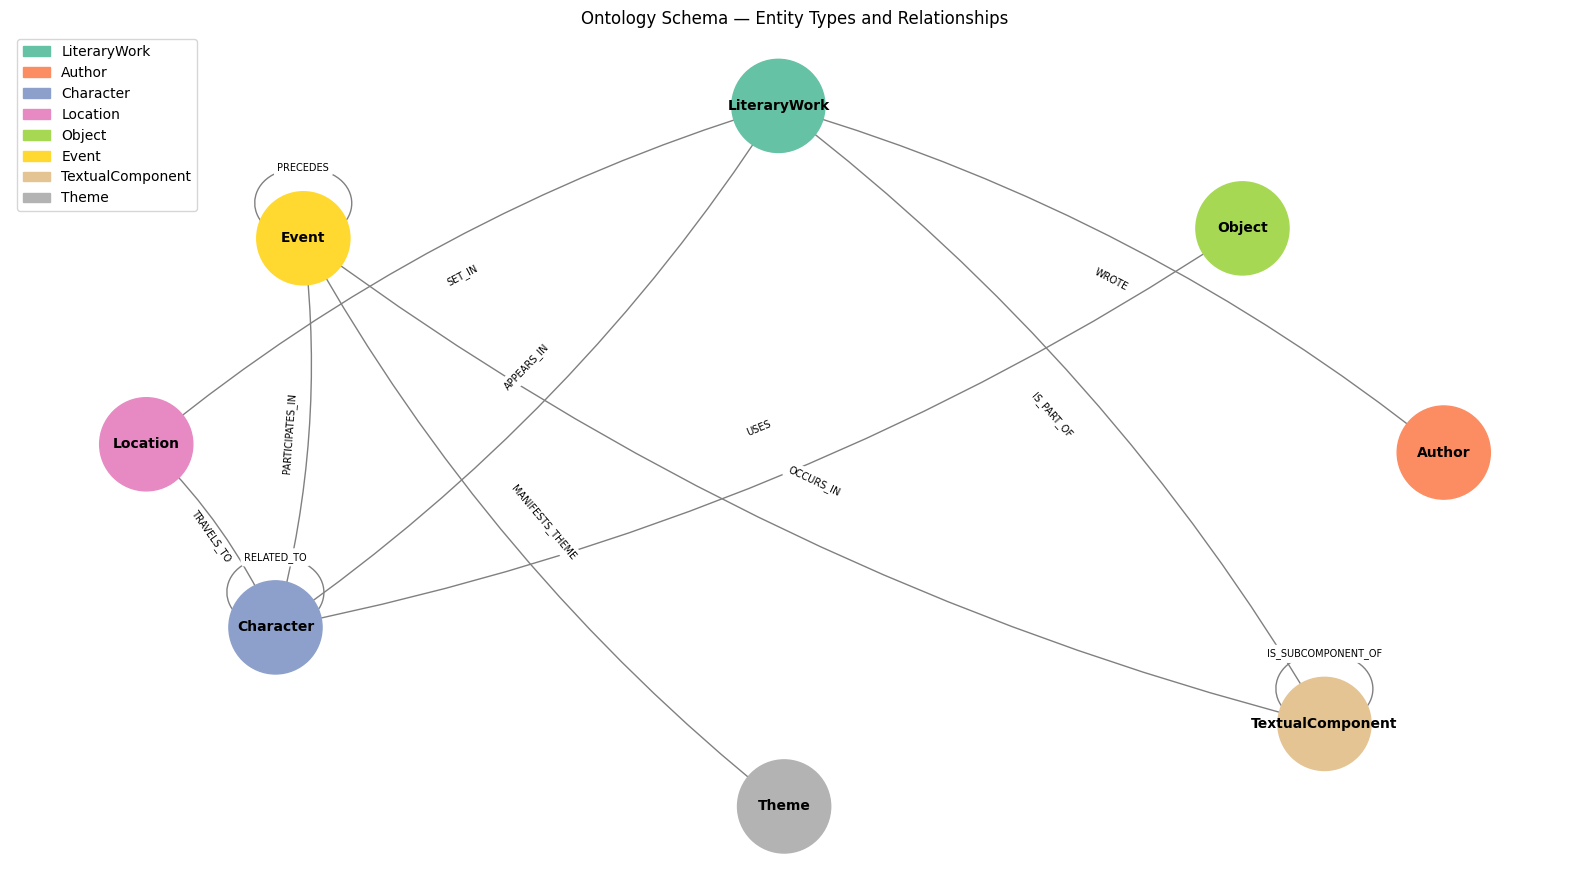

In [60]:
def plot_ontology_graph(schema: OntologySchema) -> None:
    """
    Directed graph with colored nodes and labeled edges.
    """
    G = nx.DiGraph()
    cmap = plt.cm.Set2
    type_colors: dict[str, tuple] = {}

    for i, et in enumerate(schema.entity_types):
        type_colors[et.name] = cmap(i / max(len(schema.entity_types), 1))
        G.add_node(et.name)

    for rt in schema.relationship_types:
        G.add_edge(rt.source_type, rt.target_type, label=rt.name)

    pos = nx.spring_layout(G, seed=42, k=3)
    colors: list = [type_colors.get(n, "lightgray") for n in G.nodes]
    fig, ax = plt.subplots(figsize=(16, 9))
    
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=4500, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True, arrowsize=20, connectionstyle="arc3,rad=0.1", ax=ax)
    nx.draw_networkx_edge_labels(G, pos, nx.get_edge_attributes(G, "label"), font_size=7, ax=ax)
    ax.legend(handles=[mpatches.Patch(color=c, label=t) for t, c in type_colors.items()], loc="upper left")
    ax.set_title("Ontology Schema — Entity Types and Relationships")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_ontology_graph(schema)

## Schema Validation

Now we run the test extraction success rate per entity type on random passages from the corpus. For each type, we will measure what fraction of passages yield at least one successfully extracted entity. Types falling below the **70% threshold** indicate the schema definition is too ambiguous for reliable extraction and should be mdofied (for our case). Even though, we are not measuring precision (if those entity extracted are actually correct), but only recall. Moreover, we are taking random chapters, not knowing which one represents our Taxonomy accurately. 

Therefore, our validation approach is not entirely a representation of what eaach book contains, but use an indirect measure to see whether the schema's entity types are concrete and distinguishable enoguh for the extraction model. It's more of a sanity check to confirm if our entity are good enough. 

In [61]:
class ExtractedEntity(BaseModel):
    """
    A single entity extracted from a passage.
    """
    name: str = Field(description="Entity name as it appears in text")
    entity_type: str = Field(description="One of the allowed entity types")
    confidence: float = Field(ge=0.0, le=1.0, description="Extraction confidence")


class PassageExtractionResult(BaseModel):
    """
    All entities extracted from one passage.
    """
    entities: list[ExtractedEntity]

validation_extraction_prompt = """You are an entity extraction system for literary texts.

## Allowed Entity Types
{entity_types}

## Passage
{passage}

## Task
Extract all entities from the passage above. For each entity provide:
- name: the entity's name as it appears in text
- entity_type: one of the allowed types listed above
- confidence: 0.0 to 1.0 how certain you are this is correct

Extract only entities that clearly match one of the allowed types.
Return ONLY the structured response.
"""

In [33]:
def extract_entities_from_passage(passage: str, schema: OntologySchema, *, model: str) -> PassageExtractionResult:
    """
    Extract entities from a single passage using the schema.
    """
    et_text: str = "\n".join(f"- {et.name}: {et.description}" for et in schema.entity_types)
    client = instructor.from_openai(OpenAI(), mode=instructor.Mode.JSON)

    return client.chat.completions.create(
        model=model, response_model=PassageExtractionResult,
        messages=[{"role": "user", "content": validation_extraction_prompt.format(
            entity_types=et_text, passage=passage)}])

passage = list(book_chapters.values())[0][0][1][:500]
extract_entities_from_passage(passage, schema, model="google/gemini-2.5-pro")

PassageExtractionResult(entities=[ExtractedEntity(name='thou', entity_type='Character', confidence=0.9), ExtractedEntity(name='His tender heir', entity_type='Character', confidence=0.85), ExtractedEntity(name='Thyself', entity_type='Character', confidence=0.9), ExtractedEntity(name='increase', entity_type='Theme', confidence=0.95), ExtractedEntity(name='beauty', entity_type='Theme', confidence=0.95), ExtractedEntity(name='decease', entity_type='Event', confidence=0.7), ExtractedEntity(name='memory', entity_type='Theme', confidence=0.9)])

In [40]:
def validate_schema(schema: OntologySchema, book_chapters: dict[str, list[tuple[str, str]]], *, model: str,
                    n_passages: int = 20, passage_words: int = 800) -> dict[str, float]:
    """
    Test extraction success rate per entity type on random passages.
    """
    all_passages: list[str] = []

    for chapters in book_chapters.values():
        for _, body in chapters:
            words: list[str] = body.split()
            for i in range(0, max(len(words) - passage_words, 1), passage_words):
                all_passages.append(" ".join(words[i : i + passage_words]))

    selected: list[str] = random.sample(all_passages, min(n_passages, len(all_passages)))
    type_hits: dict[str, int] = {et.name: 0 for et in schema.entity_types}

    for i, passage in enumerate(selected):
        found: set[str] = {e.entity_type for e in extract_entities_from_passage(passage, schema, model=model).entities}
        for t in found:
            if t in type_hits:
                type_hits[t] += 1

    return {t: hits / len(selected) for t, hits in type_hits.items()}

results = validate_schema(schema, book_chapters, model="google/gemini-2.5-pro")

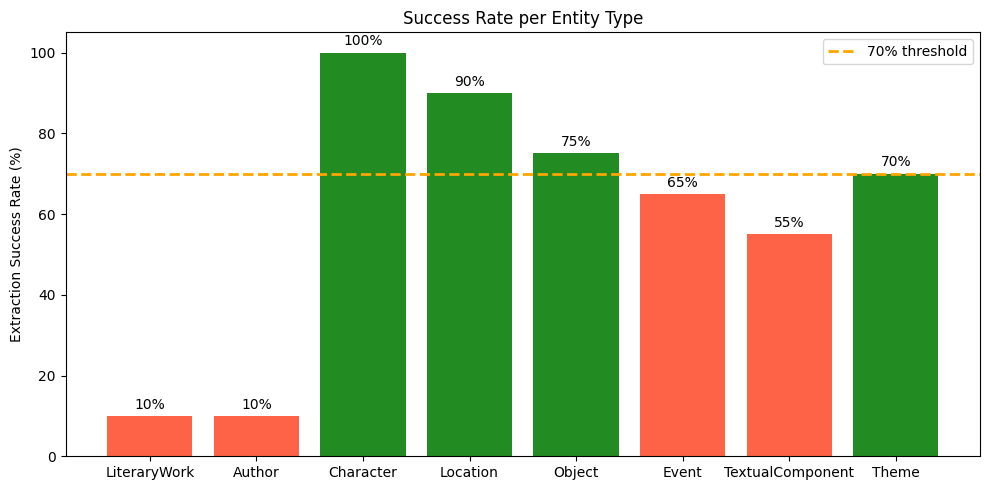

In [42]:
def plot_validation_results(results: dict[str, float]) -> None:
    """
    Bar chart of extraction success rate with 70% threshold line.
    """
    types: list[str] = list(results.keys())
    rates: list[float] = [results[t] * 100 for t in types]
    colors: list[str] = ["forestgreen" if r >= 70 else "tomato" for r in rates]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(types, rates, color=colors)
    ax.axhline(y=70, color="orange", linestyle="--", linewidth=2, label="70% threshold")
    ax.bar_label(bars, fmt="%.0f%%", padding=3)
    ax.set_ylabel("Extraction Success Rate (%)")
    ax.set_title("Success Rate per Entity Type")
    ax.set_ylim(0, 105)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_validation_results(results)

LiteraryWork and Theme are by default hard to stop in random passages, they concerns mostly summarization, or cross-book references so we don't have to worry about them. 
Object and Location entities are indeed fine, per obivous logic (they might just be under represented in our randomly extracted passages). Event is high enough. 

After couple of trials, where we increased the number of words per passage, we are satisfied with these findingss 


## Extraction Testing

Now we run constrained triple extraction on 2/3 chapters from selected books to validate the ontology end-to-end. Each triple must use entity types and relationship types from the schema. Results are visualized as a knowledge graph (networkx, colored by entity type) and bar charts showing triple counts by type.

This is necessary before investing time and money for the extraction on every book. It helps us test our schema and verify it on a larger subset. 


In [44]:
class Triple(BaseModel):
    """
    A single (subject, predicate, object) triple.
    """
    subject: str = Field(description="Subject entity name")
    subject_type: str = Field(description="Subject entity type from schema")
    predicate: str = Field(description="Relationship type from schema")
    object: str = Field(description="Object entity name")
    object_type: str = Field(description="Object entity type from schema")
    confidence: float = Field(ge=0.0, le=1.0)
    source_text: str = Field(description="Exact sentence(s) supporting this triple")

class ExtractionResponse(BaseModel):
    """
    All triples extracted from one passage.
    """
    triples: list[Triple]

extraction_prompt = """You are a knowledge graph extraction system for literary texts.

## Schema
Entity types: {entity_types}
Relationship types: {relationship_types}

## Passage
{passage}

## Task
Extract all (subject, predicate, object) triples from the passage.
Each triple MUST use entity types and relationship types from the schema above.

For each triple provide:
- subject / subject_type: entity name and its type from the schema
- predicate: relationship type from the schema
- object / object_type: entity name and its type from the schema
- confidence: 0.0 to 1.0
- source_text: the exact sentence(s) supporting this triple

Extract only triples explicitly supported by the passage text.
Return ONLY the structured response.
"""

In [45]:
def extract_triples(passage: str, schema: OntologySchema, *, model: str) -> ExtractionResponse:
    """
    Extracting schema constrained triples from a passage fro testing.
    """
    et_text: str = ", ".join(schema.entity_type_names())
    rt_text: str = ", ".join(schema.relationship_type_names())
    client = instructor.from_openai(OpenAI(), mode=instructor.Mode.JSON)

    return client.chat.completions.create(
        model=model, response_model=ExtractionResponse,
        temperature=0.1,
        messages=[{"role": "user", "content": extraction_prompt.format(
            entity_types=et_text, relationship_types=rt_text, passage=passage)}])

chapter_text = book_chapters["frankenstein"][0][1]
extract_triples(chapter_text, schema, model="google/gemini-2.5-pro")


ExtractionResponse(triples=[Triple(subject='R. Walton', subject_type='Character', predicate='WROTE', object='Letter to Mrs. Saville', object_type='TextualComponent', confidence=1.0, source_text='To Mrs. Saville, England. St. Petersburgh, Dec. 11th, 17—. ... Your affectionate brother, R. Walton'), Triple(subject='R. Walton', subject_type='Character', predicate='RELATED_TO', object='Margaret Saville', object_type='Character', confidence=1.0, source_text='my first task is to assure my dear sister of my welfare... Farewell, my dear, excellent Margaret... Your affectionate brother, R. Walton'), Triple(subject='R. Walton', subject_type='Character', predicate='PARTICIPATES_IN', object='Arctic expedition', object_type='Event', confidence=1.0, source_text='You will rejoice to hear that no disaster has accompanied the commencement of an enterprise which you have regarded with such evil forebodings.'), Triple(subject='R. Walton', subject_type='Character', predicate='TRAVELS_TO', object='St. Peter

In [48]:
def run_extraction_test(schema: OntologySchema, book_chapters: dict[str, list[tuple[str, str]]], *, model: str, book_keys: list[str] | None = None, n_chapters: int = 3) -> list[Triple]:
    """
    Run triple extraction on a few chapters from selected books.
    """
    if book_keys is None:
        book_keys = random.sample(list(book_chapters.keys()), 2)

    all_triples: list[Triple] = []

    for key in book_keys:
        for title, body in book_chapters[key][:n_chapters]:
            print(f"Extracting from {key} — {title}...")
            result: ExtractionResponse = extract_triples(body, schema, model=model)
            all_triples.extend(result.triples)
            print(f"  {len(result.triples)} triples")
    print(f"\nTotal: {len(all_triples)} triples")

    return all_triples

all_triples = run_extraction_test(schema, book_chapters, model="google/gemini-2.5-pro")

Extracting from great_gatsby — VII...
  25 triples
Extracting from great_gatsby — V...
  9 triples
Extracting from great_gatsby — I...
  4 triples
Extracting from frankenstein — Letter 1...
  16 triples
Extracting from frankenstein — Letter 2...
  16 triples
Extracting from frankenstein — Letter 3...
  13 triples

Total: 83 triples


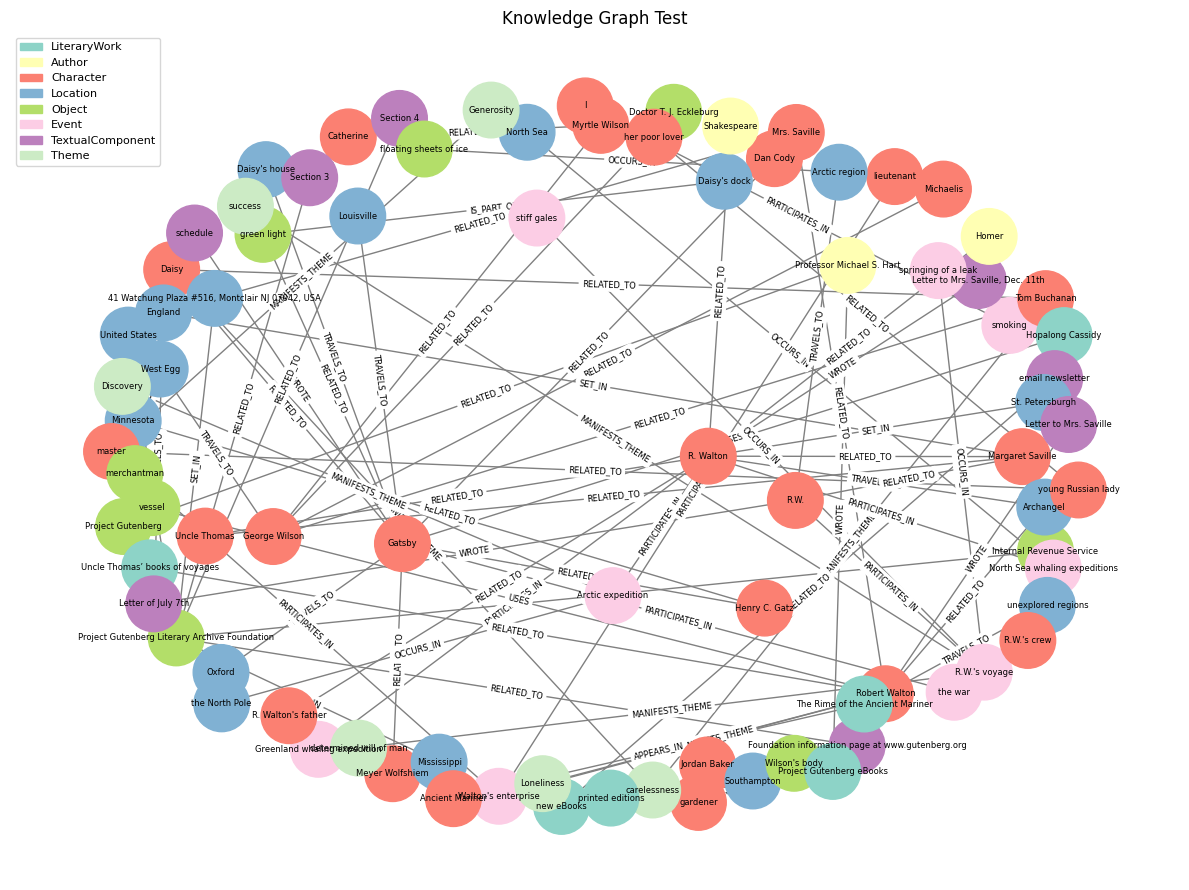

In [65]:
def plot_knowledge_graph(triples: list[Triple], schema: OntologySchema) -> None:
    """
    Render extracted triples as a colored knowledge graph.
    """
    G = nx.DiGraph()
    cmap = plt.cm.Set3
    type_colors: dict[str, tuple] = {et.name: cmap(i / max(len(schema.entity_types), 1)) for i, et in enumerate(schema.entity_types)}
    for t in triples:
        G.add_node(t.subject, type=t.subject_type)
        G.add_node(t.object, type=t.object_type)
        G.add_edge(t.subject, t.object, label=t.predicate)
    pos = nx.spring_layout(G, seed=42, k=1.5)
    colors: list = [type_colors.get(G.nodes[n].get("type", ""), "lightgray") for n in G]
    fig, ax = plt.subplots(figsize=(12, 9))
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1600, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True, arrowsize=9, ax=ax)
    nx.draw_networkx_edge_labels(G, pos, nx.get_edge_attributes(G, "label"), font_size=6, ax=ax)
    ax.legend(handles=[mpatches.Patch(color=c, label=t) for t, c in type_colors.items()], loc="upper left", fontsize=8)
    ax.set_title("Knowledge Graph Test")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_knowledge_graph(all_triples, schema)

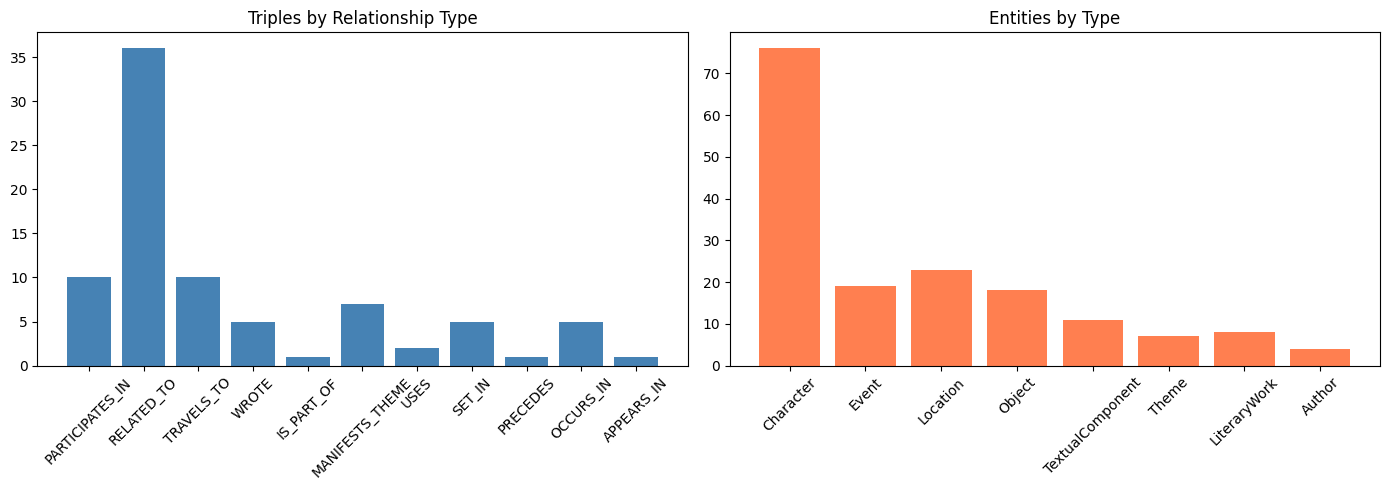

In [ ]:
def plot_extraction_stats(triples: list[Triple], schema: OntologySchema) -> None:
    """
    Bar charts: triple counts by relationship type and entity type.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    rel_counts: dict[str, int] = {}
    for t in triples:
        rel_counts[t.predicate] = rel_counts.get(t.predicate, 0) + 1
    ax1.bar(rel_counts.keys(), rel_counts.<values(), color="steelblue")
    ax1.set_title("Triples by Relationship Type")
    ax1.tick_params(axis="x", rotation=45)
    ent_counts: dict[str, int] = {}
    for t in triples:
        ent_counts[t.subject_type] = ent_counts.get(t.subject_type, 0) + 1
        ent_counts[t.object_type] = ent_counts.get(t.object_type, 0) + 1
    ax2.bar(ent_counts.keys(), ent_counts.values(), color="coral")
    ax2.set_title("Entities by Type")
    ax2.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

plot_extraction_stats(all_triples, schema)

The distribution reflect the power law distribution, which is expected in knowledge graphs extracted from natural language. Only a few types carry most of the triples, and a long tail carries the rest. 

## Book Summarization

We need to generate a 500 word summary per book for the thematic agent's book level vector index. Summaries are embedded using NVIDIA NV-Embed-v2 from HuggingFace and saved to `data/book_summaries.json`. It's shown to be the best embedding model on the recent benchmarks. It aqlso has 4096dim embeddings, capturing more semantic signal. Probably an overkill here, but why not :) 

At query time, the thematic agent performs dense search over these embeddings for broad thematic and exploratory queries.

In [18]:
class BookSummary(BaseModel):
    """
    A book-level summary for the thematic agent.
    """
    book_key: str = Field(description="Key from the books dict")
    title: str = Field(description="Full book title")
    summary: str = Field(description="800 word cohesive summary")


summary_prompt = """Summarize the following book in approximately 800 words. Cover:
- Main characters and their roles
- Central plot and key events
- Major themes
- Setting and time period
- Narrative style

## Book Title
{title}

## Full Text
{text}

Write a cohesive, paragraph-form summary. Do not use bullet points.
"""

In [ ]:
summary_path: Path = data_dir / "book_summaries.json"

def generate_summary(text: str, title: str, book_key: str, *, model: str, max_chars: int = 200_000) -> BookSummary:
    """

    Generate a 800 word summary for one book.
    """
    client = instructor.from_openai(OpenAI(), mode=instructor.Mode.JSON)
    return client.chat.completions.create(
        model=model, response_model=BookSummary,
        temperature=0.3,
        messages=[{"role": "user", "content": summary_prompt.format(title=title, text=text[:max_chars])}])

def generate_all_summaries(corpus: dict[str, str], *, model: str) -> list[BookSummary]:  
    if summary_path.exists():
        print(f"Loading cached summaries from {summary_path}")
        raw: list[dict] = json.loads(summary_path.read_text())             
        return [BookSummary(**s) for s in raw] 

    summaries: list[BookSummary] = []
    for key, text in corpus.items():
        meta = book_metadata[key]
        s = generate_summary(text, meta["title"], key, model=model)
        summaries.append(s)
        print(f" {key}: {len(s.summary.split())} words")
    summary_path.write_text(json.dumps([s.model_dump() for s in summaries], indent=2, ensure_ascii=False))                                            
    return summaries 

summaries = generate_all_summaries(corpus, model="google/gemini-2.5-pro")

 shakespeare_complete: 662 words
 beowulf: 650 words
 prince: 664 words
 count_of_monte_cristo: 556 words
 dracula: 637 words
 frankenstein: 788 words
 pride_and_prejudice: 814 words
 alice_in_wonderland: 726 words
 great_gatsby: 686 words


In [33]:
from vertexai.language_models import TextEmbeddingModel, TextEmbeddingInput
import vertexai
import os
vertexai.init(project=os.environ["GCP_PROJECT"], location=os.environ["GCP_LOCATION"])   

embed_model = TextEmbeddingModel.from_pretrained("text-embedding-005")   

def embed_summaries(summaries: list[BookSummary]) ->  list[list[float]]:
    """
    Embed book summaries using a sentence transformer model.
    """
    texts = [TextEmbeddingInput(text=s.summary, task_type="RETRIEVAL_DOCUMENT") for s in summaries]  
    embeddings = embed_model.get_embeddings(texts)                                
    return [e.values for e in embeddings]

embeddings = embed_summaries(summaries)  


In [34]:
def save_summaries(summaries: list[BookSummary], embeddings: list[list[float]]) -> Path:                                                
    """                                                   
    Save summaries and embeddings to data/book_summaries.json.
    """
    output: list[dict] = [                                                 
        {"book_key": s.book_key, "title": s.title, "summary": s.summary,
        "embedding": embeddings[i]}                                       
        for i, s in enumerate(summaries)]
    path: Path = data_dir / "book_summaries.json"                          
    path.write_text(json.dumps(output, indent=2, ensure_ascii=False))
    return path                                           

save_summaries(summaries, embeddings)

PosixPath('../data/book_summaries.json')

## Schema Export

Finally, we save the finalized `OntologySchema` to `data/schema.json`. This file is the single
source of truth for downstream ingestion, where all triple extraction, entity resolution,
and validation steps read from this schema.

In [62]:
def export_schema(schema: OntologySchema) -> Path:
    """
    It saves the finalized ontology schema to data/schema.json for later extraction
    """
    path: Path = data_dir / "schema.json"
    path.write_text(schema.model_dump_json(indent=2), encoding="utf-8")
    return path

export_schema(schema)

PosixPath('../data/schema.json')